# Merge and Export Machine Learning Dataset
This notebook gathers all the pre-calculated features from the other scripts (OSM POIs, Land Use percentages, and Terrain Slope) and merges them into one single comprehensive `.csv` table that will be fed to the Machine Learning models.

## Note: Data Requirements

In [36]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datatsets

In [37]:
# Define file paths (UNCOMMENT AND ADJUST ONCE YOU HAVE EXPORTED THE DATA)

path_osm_roads = "data/osm_roads_noise_class.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points = "data/osm_points_features.csv"
path_osmlanduse = "data/osm_landuse_features.csv"

df_osm_roads = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points = pd.read_csv(path_osm_points)
df_osm_landuse = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [38]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,21638868_30343649_0,2,2,1,4,1462.932115,2131.092865,492.904878,0.000000,0.000000,0.000000
1,21638865_30343650_0,1,1,0,6,1420.227896,2300.048237,675.721286,192.974974,0.000000,0.000000
2,13859746868_13859746870_0,3,2,2,5,232.687902,502.124710,1111.341716,188.971039,0.000000,385.612798
3,21638917_190981834_0,4,4,3,3,588.464995,1609.386075,0.000000,58.492257,162.714827,48.558225
4,21638891_190971702_0,3,3,3,4,1432.029299,1409.121451,149.242081,0.000000,151.351124,184.454492


In [39]:
df_momepy_roads.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,21638845_885308258_0,43.025602,0.750000,0.000896,0.000147,0.000006,0.798398
1,21638845_13175411896_0,26.114886,0.363095,0.002015,0.000154,0.000011,0.812345
2,21638865_30343650_0,15.135908,0.750000,0.002015,0.000154,0.000011,0.812345
3,21638867_1636238503_0,18.154330,0.666667,0.000896,0.000147,0.000006,0.798799
4,21638867_1403082237_0,20.158620,0.666667,0.000672,0.000145,0.000008,0.796396


In [40]:
df_osm_points.head()

,road_id,signals,transport,pois
0,21638845_885308258_0,0.105877,0.000000,0.070585
1,21638845_13175411896_0,0.022710,0.008111,0.014599
2,21638865_30343650_0,0.000000,0.000000,0.427369
3,21638867_1636238503_0,0.063558,0.000000,0.254232
4,21638867_1403082237_0,0.064862,0.000000,0.194587


In [41]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,21638845_885308258_0,9.169742,0.0,0.0
1,21638845_13175411896_0,1.024610,0.0,0.0
2,21638865_30343650_0,0.000000,0.0,0.0
3,21638867_1636238503_0,0.000000,0.0,0.0
4,21638867_1403082237_0,0.000000,0.0,0.0


## Merge dataframes

In [42]:
# Function to merge feature DataFrame with base DataFrame

def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    # Drop target columns
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    
    # Drop duplicate columns (except road_id)
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    
    # Ensure road_id exists and is consistent
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    
    return base_df.merge(clean_df, on='road_id', how='left')

In [43]:

ml_dataset = df_osm_roads.copy()

# Columns to remove to avoid repetition
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

# Check road_id types before merging
print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points', df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse', df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,pois,width,openness,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,21638868_30343649_0,2,2,1,4,1462.932115,2131.092865,492.904878,0.000000,0.000000,...,0.199193,36.205524,0.833333,0.000225,0.000161,0.000016,0.825786,0.000000,0.0,0.0
1,21638865_30343650_0,1,1,0,6,1420.227896,2300.048237,675.721286,192.974974,0.000000,...,0.427369,15.135908,0.750000,0.002015,0.000154,0.000011,0.812345,0.000000,0.0,0.0
2,13859746868_13859746870_0,3,2,2,5,232.687902,502.124710,1111.341716,188.971039,0.000000,...,0.260610,43.790595,0.875000,0.000405,0.000186,0.000017,0.806515,6.628055,0.0,0.0
3,21638917_190981834_0,4,4,3,3,588.464995,1609.386075,0.000000,58.492257,162.714827,...,0.000000,50.000000,1.000000,0.000085,0.000169,0.000049,0.832972,0.000000,0.0,0.0
4,21638891_190971702_0,3,3,3,4,1432.029299,1409.121451,149.242081,0.000000,151.351124,...,0.052216,50.000000,1.000000,0.004815,0.000168,0.000046,0.831922,0.000000,0.0,0.0
5,21638891_533663031_0,4,4,3,4,1270.551469,1409.121451,0.000000,0.000000,157.120484,...,0.030567,37.863254,0.750000,0.004815,0.000168,0.000046,0.831922,0.000000,0.0,0.0
6,21638889_190987748_0,3,3,2,4,1428.134601,1499.848648,0.000000,0.000000,140.852971,...,0.039589,27.689208,0.750000,0.000575,0.000166,0.000045,0.828991,6.428098,0.0,0.0
7,21638882_1636238518_0,2,2,2,5,1456.395558,1841.803093,203.294825,58.347645,0.000000,...,0.173466,6.549821,0.250000,0.002416,0.000168,0.000050,0.829978,0.000000,0.0,0.0
8,21638878_242317164_0,1,1,0,5,1533.547449,2058.162204,420.707644,90.770303,0.000000,...,0.410722,7.142476,0.500000,0.002529,0.000168,0.000048,0.831058,0.000000,0.0,0.0
9,21638877_30343573_0,2,2,1,5,1462.912355,1978.443916,341.179073,91.147930,0.000000,...,0.151871,6.850539,0.388889,0.000183,0.000163,0.000037,0.824051,0.000000,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 11711 entries, 0 to 11710
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                11711 non-null  str    
 1   noise_day              11711 non-null  int64  
 2   noise_evening          11711 non-null  int64  
 3   noise_night            11711 non-null  int64  
 4   road_category          11711 non-null  int64  
 5   dist_to_trunk          11711 non-null  float64
 6   dist_to_primary        11711 non-null  float64
 7   dist_to_secondary      11711 non-null  float64
 8   dist_to_tertiary       11711 non-null  float64
 9   dist_to_residential    11711 non-null  float64
 10  dist_to_living_street  11711 non-null  float64
 11  signals                11711 non-null  float64
 12  transport              11711 non-null  float64
 13  pois                   11711 non-null  float64
 14  width                  11711 non-null  float64
 15  openness     

## Noise distribution

    Day  Evening   Night
0   128      159   367.0
1   520      764  2066.0
2  3422     4160  5861.0
3  6199     5991  3417.0
4  1442      637     NaN


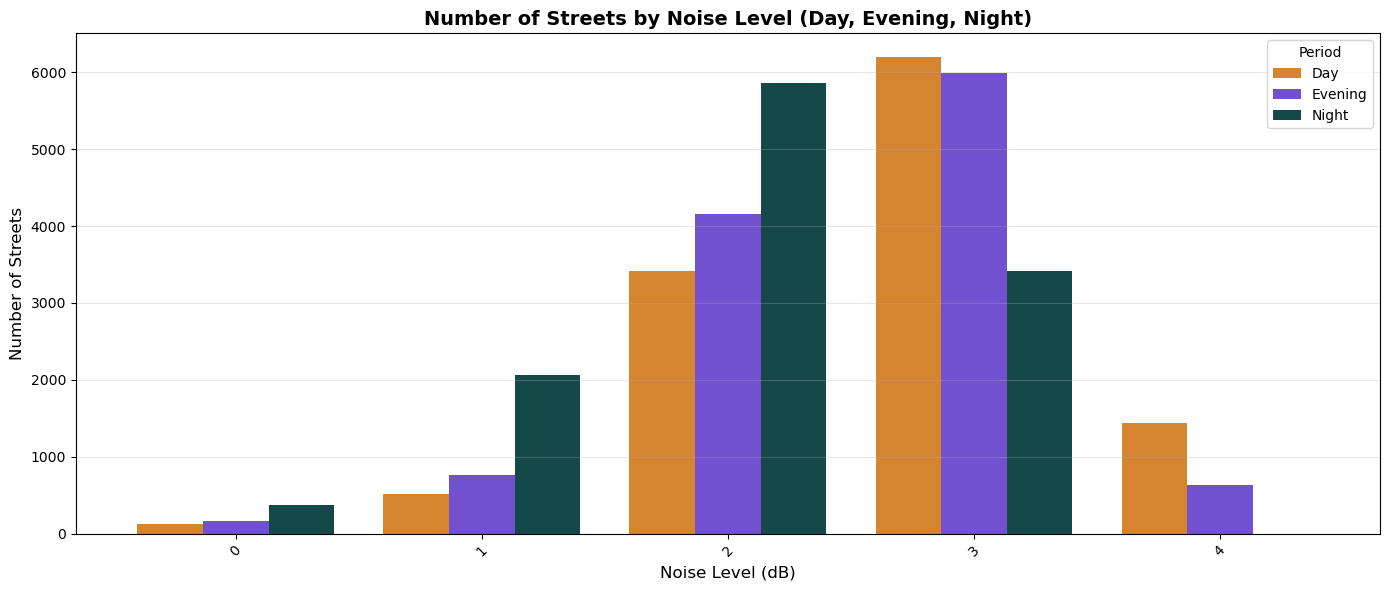

In [44]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_day = ml_dataset.groupby('noise_day').size()
counts_evening = ml_dataset.groupby('noise_evening').size()
counts_night = ml_dataset.groupby('noise_night').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Day': counts_day,
    'Evening': counts_evening,
    'Night': counts_night
})

print(comparison_df)
comparison_df[['Day', 'Evening', 'Night']].plot(kind='bar', ax=ax,width=0.8,color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export to CSV
Finally, we dump out the master table into a standard format readable by `scikit-learn` in the next phase!

In [45]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_class_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_class_ml_dataset.csv


## Engineered features

In [46]:
ml_dataset.info()
ml_dataset['width_x_betw'] = ml_dataset['width'] * ml_dataset['betweenness']
ml_dataset['dist_to_arterial'] = ml_dataset[['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary','dist_to_tertiary']].min(axis=1)
ml_dataset['dist_to_local_road'] = ml_dataset[['dist_to_residential', 'dist_to_living_street']].min(axis=1)
ml_dataset.drop(columns=['openness','betweenness'], inplace=True)
print(ml_dataset)

<class 'pandas.DataFrame'>
RangeIndex: 11711 entries, 0 to 11710
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                11711 non-null  str    
 1   noise_day              11711 non-null  int64  
 2   noise_evening          11711 non-null  int64  
 3   noise_night            11711 non-null  int64  
 4   road_category          11711 non-null  int64  
 5   dist_to_trunk          11711 non-null  float64
 6   dist_to_primary        11711 non-null  float64
 7   dist_to_secondary      11711 non-null  float64
 8   dist_to_tertiary       11711 non-null  float64
 9   dist_to_residential    11711 non-null  float64
 10  dist_to_living_street  11711 non-null  float64
 11  signals                11711 non-null  float64
 12  transport              11711 non-null  float64
 13  pois                   11711 non-null  float64
 14  width                  11711 non-null  float64
 15  openness     

In [47]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_class_ml_enriched.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_class_ml_enriched.csv


## Subsample

In [48]:
import pandas as pd

# Assume your DataFrame is called df and the noise column is 'noise_day'
# Set the desired sample size (e.g., 1000)
sample_size = 5000

# Calculate the proportion of each noise value in the original data
proportions = ml_dataset['noise_day'].value_counts(normalize=True).sort_index()

# Calculate how many samples to take for each noise value
samples_per_value = (proportions * sample_size).round().astype(int)

# Subsample for each noise value
subsampled = pd.concat([
    ml_dataset[ml_dataset['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

# Shuffle the result
subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
0    0.010998
1    0.044391
2    0.292142
3    0.529294
4    0.123175
Name: proportion, dtype: float64


## Before and after sampling

           Before  After
noise_day               
0             128     55
1             520    222
2            3422   1461
3            6199   2647
4            1442    616


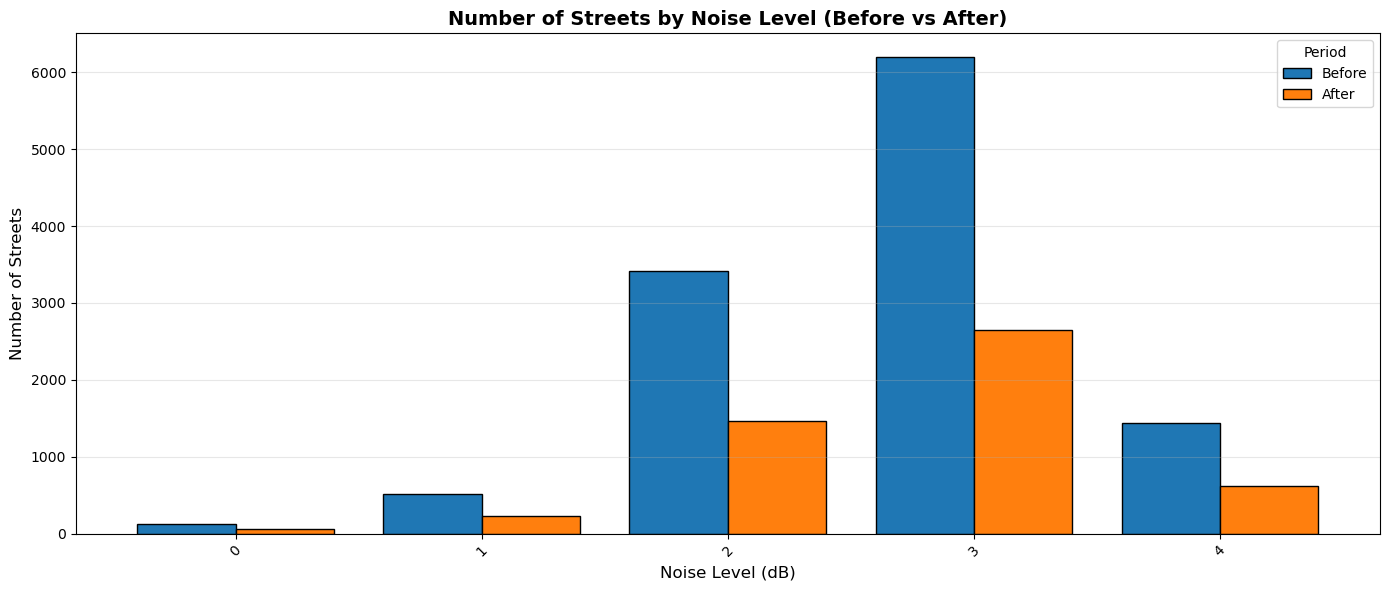

In [49]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_before = ml_dataset.groupby('noise_day').size()
counts_after = subsampled.groupby('noise_day').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Before': counts_before,
    'After': counts_after
})

print(comparison_df)
comparison_df[['Before', 'After']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export CSV

In [50]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_class_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_class_ml_subsample.csv
